# HW 16 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 16th, 2025 at 11:59pm** on Gradescope

**Make sure to work on this notebook in DataHub!**

# 1) Recap of lecture
**Copy and paste** your code from lecture for the neural network with the **default** settings (i.e. before we improved the model). Make sure to also import the `data.py` file. 

In [ ]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Iteration 0, Loss: 1.1004940271377563
Iteration 100, Loss: 0.38868990540504456
Iteration 200, Loss: 0.2157706767320633
Iteration 300, Loss: 0.1376684010028839
Iteration 400, Loss: 0.10448155552148819
Iteration 500, Loss: 0.09069429337978363
Iteration 600, Loss: 0.07883021235466003
Iteration 700, Loss: 0.07041164487600327
Iteration 800, Loss: 0.062070347368717194
Iteration 900, Loss: 0.05604773387312889
Iteration 1000, Loss: 0.04719626531004906


<function matplotlib.pyplot.show(close=None, block=None)>

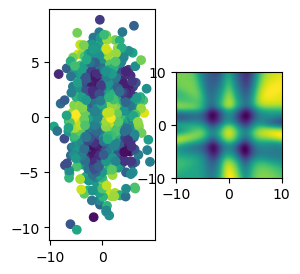

In [19]:
# Your code here

import data
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.subplot(1,2,1)
plt.scatter(data.x_values,data.y_values,c=data.color_values)

import torch
model=torch.nn.Sequential(
    torch.nn.Linear(2,50), #the X and y going into our function (50 is how many layers our data is going to go through)
    torch.nn.Sigmoid(), #hidden layer
    torch.nn.Linear(50,1), #Z output (these numbers should match 50 and 50)
)
#Loss function
loss_fn=torch.nn.MSELoss()

#Optimizer
optimizer=torch.optim.Adam(model.parameters(),lr=1e-2)

for t in range(1100):
    y_predict=model(data.x)
    loss=loss_fn(y_predict,data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t%100==0:
        print(f"Iteration {t}, Loss: {loss.item()}")
        
plt.subplot(1,2,2)
new_x=torch.linspace(-10,10,100)
grid=torch.stack(torch.meshgrid(new_x,new_x),dim=2)
output=model(grid).detach()
plt.imshow(output,extent=(-10,10,-10,10))
plt.show



What is the difference between artificial intelligence, machine learning and deep learning?

In [ ]:
# Your comment here 
"""
AI: Broad concept that mimics human intelligence
ML: subset of AI that learns from data
DL: subset of ML that uses artificial neural networks 
"""

What is a neural network?

In [ ]:
# Your comment here
"""
A model that is structured to function like the human brain. It has many layers that process 
information that allows the system mto make predictions about data sets
"""

In lecture, we used `torch.nn.Linear(2, 50)`. What do the numbers `2` and `50` represent? 

In [1]:
# Your comment here
"""
2 is the input size, and 50 is the output size
"""

What does the activation function do?

In [ ]:
# Your comment here
"""
It enables the model to learn a pattern that isnt necessarily a linear relationship
"""

What is a loss function? Why do we need one?

In [ ]:
# Your comment here
"""
Measures how well a neural network's predictions match the target values. It is necessary to have 
one because it optimizes the model and evaluates its performance
"""

Why do we call `optimizer.zero_grad()` before calling `loss.backward()`?

In [ ]:
# Your comment here
"""
it resets the gradients from the previous iterations
"""

# 2) Modifying the Neural Network
What line do you need to modify to use **30 neurons** instead of **50**? Don't change anything else. Give the original and then modified line. 

In [6]:
# Your code here
#ORIGINAL:
#torch.nn.Linear(2, 50)
#NEW:
torch.nn.Linear(2, 30)

With your default code above, run your model with **30 neurons**. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [8]:
# Your comment here
#Modified: 0.3828459084033966
#Unmodified: 0.33773064613342285

Return to **50 neurons**. Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.ReLU`. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [10]:
# Your comment here
#new: 0.2171335518360138
#old: 0.33773064613342285

Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.Tanh`? Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [ ]:
# Your comment here
#new: 0.12718245387077332
#old: 0.33773064613342285

What is the difference between `torch.nn.Sigmoid()`, `torch.nn.ReLU` and `torch.nn.Tanh`? 

In [14]:
# Your comment here 
"""
-Sigmoid: Typically used to convert probability vectors to a class value, used in the last layer of cls models
-ReLU: Used between network hidden layers.
-Tanh: Used in RNNs and in cases where zero-centered outputs are important
"""

'\n-Sigmoid: Typically used to convert probability vectors to a class value, used in the last layer of cls models\n-ReLU: Used between network hidden layers.\n-Tanh: Used in RNNs and in cases where zero-centered outputs are important\n'

Return to `torch.nn.Sigmoid()`. Change your learning rate from `1e-3` to `1e-2` in your optimizer. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [11]:
# Your comment here
#New: 0.031459324061870575
#Old:0.33773064613342285

Modify your model to have **two hidden layers** instead of one. Give that code here.

Iteration 0, Loss: 1.0317665338516235
Iteration 100, Loss: 0.28968098759651184
Iteration 200, Loss: 0.15231531858444214
Iteration 300, Loss: 0.12536942958831787
Iteration 400, Loss: 0.11407765001058578
Iteration 500, Loss: 0.10683034360408783
Iteration 600, Loss: 0.10037718713283539
Iteration 700, Loss: 0.093543142080307
Iteration 800, Loss: 0.08698101341724396
Iteration 900, Loss: 0.08233987540006638
Iteration 1000, Loss: 0.07607097178697586


<function matplotlib.pyplot.show(close=None, block=None)>

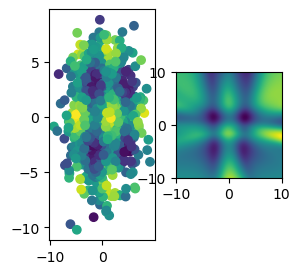

In [20]:
# Your code here
import data
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.subplot(1,2,1)
plt.scatter(data.x_values,data.y_values,c=data.color_values)

import torch
model=torch.nn.Sequential(
    torch.nn.Linear(2,50), #the X and y going into our function (50 is how many layers our data is going to go through)
    torch.nn.Sigmoid(), #hidden layer
    torch.nn.Linear(50,50), #Z output (these numbers should match 50 and 50)
    torch.nn.Sigmoid(),
    torch.nn.Linear(50,1)
)
#Loss function
loss_fn=torch.nn.MSELoss()

#Optimizer
optimizer=torch.optim.Adam(model.parameters(),lr=1e-2)

for t in range(1100):
    y_predict=model(data.x)
    loss=loss_fn(y_predict,data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t%100==0:
        print(f"Iteration {t}, Loss: {loss.item()}")
        
plt.subplot(1,2,2)
new_x=torch.linspace(-10,10,100)
grid=torch.stack(torch.meshgrid(new_x,new_x),dim=2)
output=model(grid).detach()
plt.imshow(output,extent=(-10,10,-10,10))
plt.show

# 3) More Advanced
Create a new file called `new_data.py`, make a new "hidden" function and add noise/ obscure the data (e.g. like what is done in `data.py` from lecture). Import that file here.

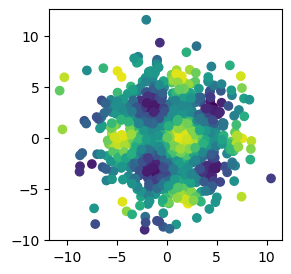

In [57]:
# Your code here
import new_data
plt.figure(figsize=(3,3))
plt.scatter(new_data.x_values,new_data.y_values,c=new_data.color_values)

Define a new model and train it **poorly** in the cell below.

Iteration 0, Loss: 1.0337324142456055


<function matplotlib.pyplot.show(close=None, block=None)>

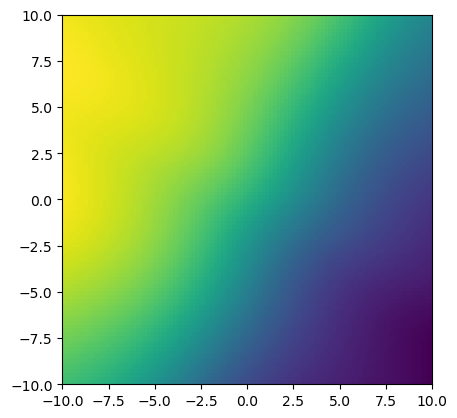

In [70]:
# Your code here
model=torch.nn.Sequential(
    torch.nn.Linear(2,5), #the X and y going into our function (50 is how many layers our data is going to go through)
    torch.nn.Sigmoid(), #hidden layer
    torch.nn.Linear(5,1), #Z output (these numbers should match 50 and 50)
)
#Loss function
loss_fn=torch.nn.MSELoss()

#Optimizer
optimizer=torch.optim.Adam(model.parameters(),lr=1e-5)

for t in range(100):
    y_predict=model(data.x)
    loss=loss_fn(y_predict,data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t%100==0:
        print(f"Iteration {t}, Loss: {loss.item()}")
        
new_x=torch.linspace(-10,10,100)
grid=torch.stack(torch.meshgrid(new_x,new_x),dim=2)
output_poor=model(grid).detach()
plt.imshow(output_poor,extent=(-10,10,-10,10))
plt.show

Improve your model and train it **well** in the cell below. (You can add more neurons, iterations, etc).

Make foure subplots (two rows, two columns). 
- (TOP LEFT) Show what the "hidden pattern" is supposed to be.
- (TOP RIGHT) Show that your "data" is.
- (BOTTOM LEFT) Show your model's prediction when you trained it poorly.
- (BOTTOM RIGHT) Show your model's prediction when you trained it well.

Iteration 0, Loss: 1.7177619934082031
Iteration 1000, Loss: 0.4116799235343933
Iteration 2000, Loss: 0.24934591352939606
Iteration 3000, Loss: 0.15025430917739868
Iteration 4000, Loss: 0.10454034060239792
Iteration 5000, Loss: 0.083330437541008
Iteration 6000, Loss: 0.06621024757623672
Iteration 7000, Loss: 0.04166555404663086
Iteration 8000, Loss: 0.030304616317152977
Iteration 9000, Loss: 0.021808790042996407


<function matplotlib.pyplot.show(close=None, block=None)>

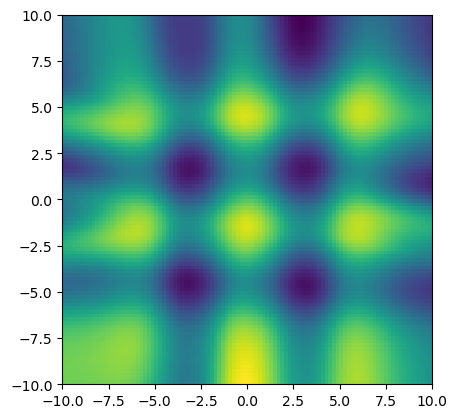

In [74]:
# Your code here
import numpy as np
model=torch.nn.Sequential(
    torch.nn.Linear(2,50), #the X and y going into our function (50 is how many layers our data is going to go through)
    torch.nn.Sigmoid(), #hidden layer
    torch.nn.Linear(50,1), #Z output (these numbers should match 50 and 50)
)
#Loss function
loss_fn=torch.nn.MSELoss()

#Optimizer
optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)

for t in range(10000):
    y_predict=model(data.x)
    loss=loss_fn(y_predict,data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t%1000==0:
        print(f"Iteration {t}, Loss: {loss.item()}")
        
new_x=torch.linspace(-10,10,100)
grid=torch.stack(torch.meshgrid(new_x,new_x),dim=2)
output_good=model(grid).detach()
plt.imshow(output_good,extent=(-10,10,-10,10))
plt.show


Text(0.5, 1.0, 'Well Trained Model')

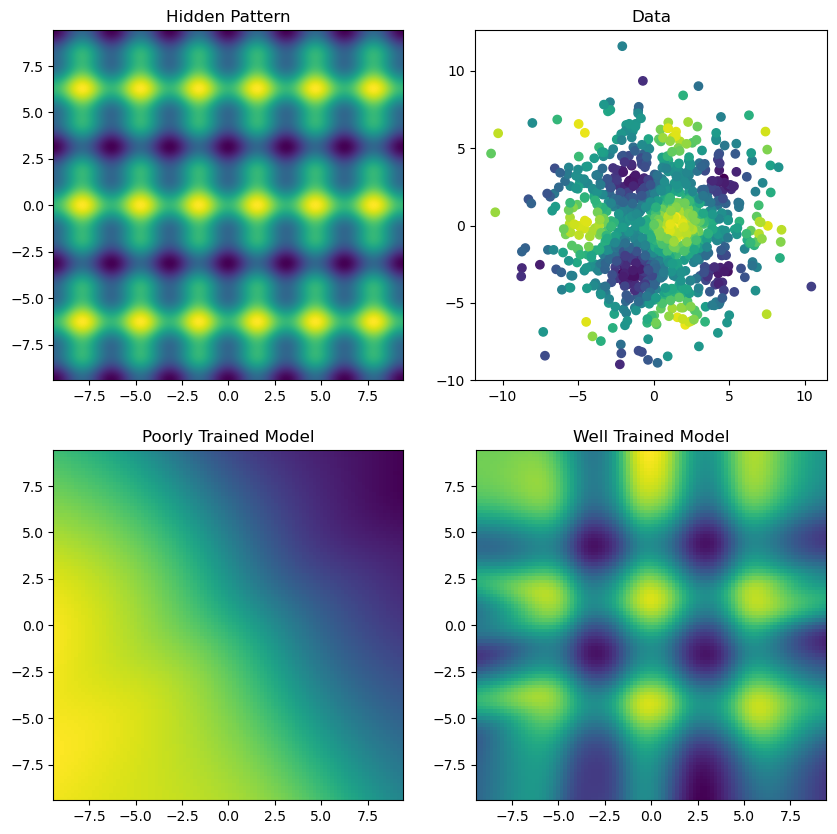

In [75]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.imshow(pattern, extent=(-3*np.pi, 3*np.pi, -3*np.pi, 3*np.pi), origin='lower', cmap='viridis')
plt.title('Hidden Pattern')

plt.subplot(2,2,2)
scatter = plt.scatter(new_data.x_values, new_data.y_values, c=new_data.color_values, cmap='viridis')
plt.title('Data')

plt.subplot(2,2,3)
plt.imshow(output_poor,extent=(-3*np.pi, 3*np.pi, -3*np.pi, 3*np.pi), origin='lower', cmap='viridis')
plt.title('Poorly Trained Model')

plt.subplot(2,2,4)
plt.imshow(output_good,extent=(-3*np.pi, 3*np.pi, -3*np.pi, 3*np.pi), origin='lower', cmap='viridis')
plt.title('Well Trained Model')

# 4) Challenge
Find some data online and build a neural network around it. Make sure to also answer these questions:
- Where did you find your data? 
- How well does your model match your data?

In [92]:
# Your code here
from sklearn.datasets import fetch_california_housing
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Dataset: I found my data by looking up "simple data sets for pytorch prediction models and then it 
#led me to this data set"
housing = fetch_california_housing()
X, y = housing.data, housing.target

Iteration 0, Loss: 3.665855646133423
Iteration 500, Loss: 0.5620754957199097


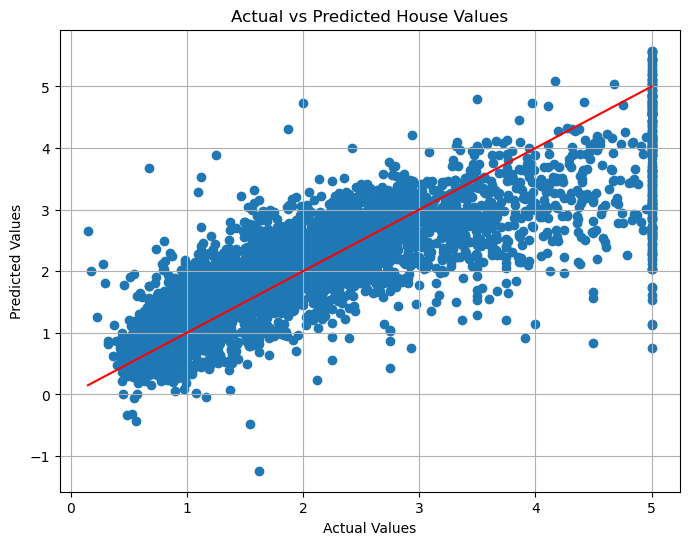

In [103]:
#had to do all these extra steps because the data set it more complicated
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

#Preprocessing and splitting into training and testing sets
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

X_train_tensor=torch.tensor(X_train, dtype=torch.float32)
y_train_tensor=torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor=torch.tensor(X_test, dtype=torch.float32)
y_test_tensor=torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

#making the actual mode:
model =torch.nn.Sequential(
    torch.nn.Linear(8, 50), 
    torch.nn.Sigmoid(),  
    torch.nn.Linear(50, 1)  
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#training loop:
for t in range(1000):
    y_predict= model(X_train_tensor)
    loss =loss_fn(y_predict, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 500 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x=torch.linspace(X_train_tensor[:, 0].min(), X_train_tensor[:, 0].max(), 100)
new_y=torch.linspace(X_train_tensor[:, 1].min(), X_train_tensor[:, 1].max(), 100)

#to plot actual against prediction:
with torch.no_grad():  
    y_pred_test=model(X_test_tensor)

# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test_tensor.numpy(), y_pred_test.numpy())
plt.plot([y_test_tensor.min(), y_test_tensor.max()], [y_test_tensor.min(), y_test_tensor.max()], color='r')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted House Values')
plt.grid()
plt.show()

In [ ]:
"""
I did a different approach with no meshgrids and instead I made a trend line that would predict the 
mean house value. The red line represents the ideal scenario where the predicted values match the 
actual values. The blue scatter plot represents what my model predicted. I would say that it follows 
the trend well since it follows the same shape and trend. 
"""

Once you are done, make sure to:
- Download this notebook and all releveant files (`new_data.py`, stuff from question 4, etc) from datahub.
- Move it to your **remote repository**.
- Upload to Gradescope!